In [9]:
!pip install pandas scipy numpy tqdm

## Dataset creation

In [2]:
import os
import pandas as pd
# Define paths
base_dir = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output"
datasets = ["train", "test", "validate"]

for dataset in datasets:
    # Construct paths using os.path.join for safety
    input_dir = os.path.join(base_dir, f"{dataset}_dataset")
    output_path = os.path.join(base_dir, f"{dataset}.csv")
    
    print(f"\nProcessing {dataset.upper()} dataset:")
    print(f"Input directory: {input_dir}")
    
    # Check if directory exists
    if not os.path.exists(input_dir):
        print(f"❌ Directory not found: {input_dir}")
        continue
    
    # Get CSV files with case-insensitive check
    csv_files = [f for f in os.listdir(input_dir) if f.lower().endswith('.csv')]
    
    if not csv_files:
        print(f"❌ No CSV files found in {input_dir}")
        continue
    
    print(f"Found {len(csv_files)} CSV files")
    print(csv_files)


Processing TRAIN dataset:
Input directory: C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\train_dataset
Found 269 CSV files
['-DZaI_yoNac_teacher_landmarks.csv', '-LB4ENHxcIs_deaf_landmarks.csv', '-LB4ENHxcIs_no_landmarks.csv', '-LB4ENHxcIs_teacher_landmarks.csv', '02NAI-ykpWk_orange_landmarks.csv', '0YnizmAgAfU_eat_landmarks.csv', '13OPrjZT9lo_no_landmarks.csv', '25ymRY7hbjs_deaf_landmarks.csv', '25ymRY7hbjs_hello_landmarks.csv', '25ymRY7hbjs_nice_landmarks.csv', '25ymRY7hbjs_teacher_landmarks.csv', '27djXV1qAss_deaf_landmarks.csv', '2nXrJ_7NOgE_eat_landmarks.csv', '2PeTh4Ym048_nice_landmarks.csv', '38kOjIIo8yQ_want_landmarks.csv', '3aXS3keR8oY_nice_landmarks.csv', '3RB642y8sgo_deaf_landmarks.csv', '3zoqSvF0Z2A_hello_landmarks.csv', '4AwP2ED0O78_teacher_landmarks.csv', '4iWzK-kKmIU_orange_landmarks.csv', '5S3qaGLdPmE_eat_landmarks.csv', '5Sb-YjNphkY_orange_landmarks.csv', '6UrcyZ-QeiU_eat_landmarks.csv', '6XcxbPfP5YQ_no_landmarks.csv', '6YIy2EVFKaA_want_landmarks.csv', '75BkNdt

## Dataset Analysis

In [1]:
import pandas as pd
import numpy as np

# Replace with your actual file paths
train_path = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\train.csv"
val_path = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\validate.csv"
test_path = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\test.csv"


def load_and_inspect_data(file_path):
    df = pd.read_csv(file_path)
    print(f"Data loaded: {file_path}")
    print("=====================================")
    print("First 3 rows:")
    print(df.head(3))
    print("\nSummary:")
    print(f"Total samples: {len(df)}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Unique classes: {df['class'].nunique()}")
    print(f"Class distribution:\n{df['class'].value_counts()}")
    return df

print("===== Training Data =====")
train_df = load_and_inspect_data(train_path)
print("\n===== Validation Data =====")
val_df = load_and_inspect_data(val_path)
print("\n===== Test Data =====")
test_df = load_and_inspect_data(test_path)

===== Training Data =====
Data loaded: C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\train.csv
First 3 rows:
              video_id    class  frame  Face_LM_0_x  Face_LM_0_y  Face_LM_0_z  \
0  -DZaI_yoNac_teacher  teacher      0     0.501489     0.291855    -0.929792   
1  -DZaI_yoNac_teacher  teacher      1     0.488614     0.272328    -1.150703   
2  -DZaI_yoNac_teacher  teacher      2     0.488635     0.252779    -0.989913   

   Face_LM_1_x  Face_LM_1_y  Face_LM_1_z  Face_LM_2_x  ...  RH_LM_17_z  \
0     0.517985     0.231718    -0.873637     0.528615  ...         0.0   
1     0.505778     0.221172    -0.946698     0.515470  ...         0.0   
2     0.501130     0.210595    -0.940724     0.511051  ...         0.0   

   RH_LM_18_x  RH_LM_18_y  RH_LM_18_z  RH_LM_19_x  RH_LM_19_y  RH_LM_19_z  \
0         0.0         0.0         0.0         0.0         0.0         0.0   
1         0.0         0.0         0.0         0.0         0.0         0.0   
2         0.0         0.0      

In [2]:
def check_missing_landmarks(df):
    # Count zeros in LH_LM and RH_LM columns
    lh_cols = [col for col in df.columns if "LH_LM" in col]
    rh_cols = [col for col in df.columns if "RH_LM" in col]
    
    lh_zero = (df[lh_cols] == 0.0).sum().sum()
    rh_zero = (df[rh_cols] == 0.0).sum().sum()
    
    total_lh = len(df) * len(lh_cols)
    total_rh = len(df) * len(rh_cols)
    
    print(f"LH_LM zeros: {lh_zero}/{total_lh} ({(lh_zero/total_lh)*100:.2f}%)")
    print(f"RH_LM zeros: {rh_zero}/{total_rh} ({(rh_zero/total_rh)*100:.2f}%)")

print("\n===== Training Data Missing Landmarks =====")
check_missing_landmarks(train_df)
print("\n===== Validation Data Missing Landmarks =====")
check_missing_landmarks(val_df)


===== Training Data Missing Landmarks =====
LH_LM zeros: 533799/1725444 (30.94%)
RH_LM zeros: 1114911/1725444 (64.62%)

===== Validation Data Missing Landmarks =====
LH_LM zeros: 70749/304479 (23.24%)
RH_LM zeros: 188685/304479 (61.97%)


In [3]:
!pip install matplotlib



===== Training Data Sequence Length =====

Sequence Length Stats:
count    269.000000
mean     101.814126
std       52.464868
min       15.000000
25%       64.000000
50%       90.000000
75%      123.000000
max      328.000000
Name: sequence_length, dtype: float64


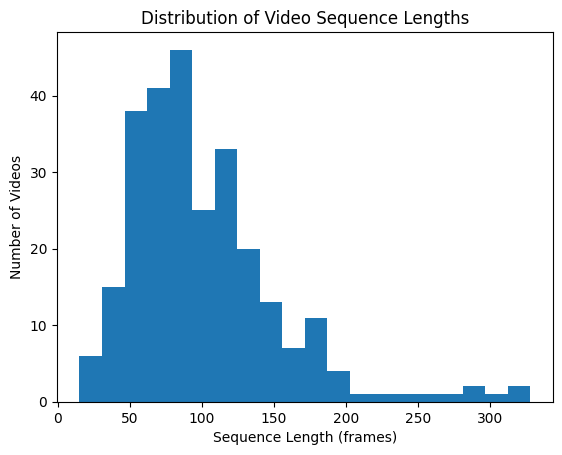

In [4]:
def analyze_sequence_length(df):
    # Extract video_id (assuming format: "[video_hash]_[class]")
    df["video_id_clean"] = df["video_id"]
    
    # Group by cleaned video_id
    video_stats = df.groupby("video_id_clean")["frame"].agg(["min", "max", "count"])
    video_stats["sequence_length"] = video_stats["max"] - video_stats["min"] + 1
    
    print("\nSequence Length Stats:")
    print(video_stats["sequence_length"].describe())
    
    # Plot histogram
    import matplotlib.pyplot as plt
    plt.hist(video_stats["sequence_length"], bins=20)
    plt.xlabel("Sequence Length (frames)")
    plt.ylabel("Number of Videos")
    plt.title("Distribution of Video Sequence Lengths")
    plt.show()

print("\n===== Training Data Sequence Length =====")
analyze_sequence_length(train_df)

Average frame count per video: 101.81


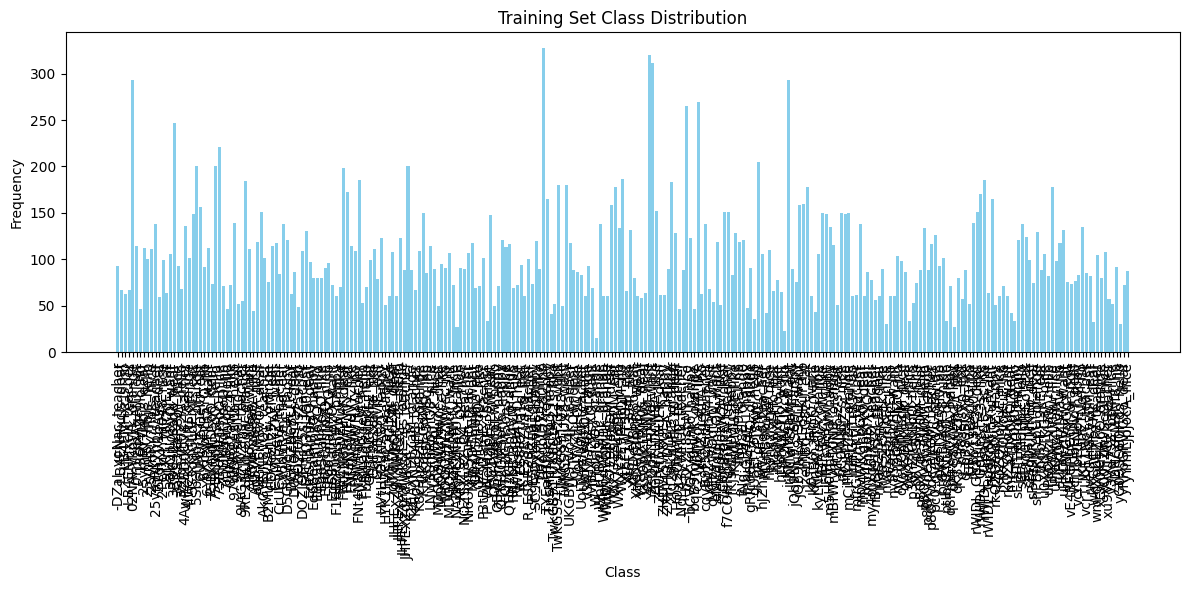

Average frame count per video: 83.33


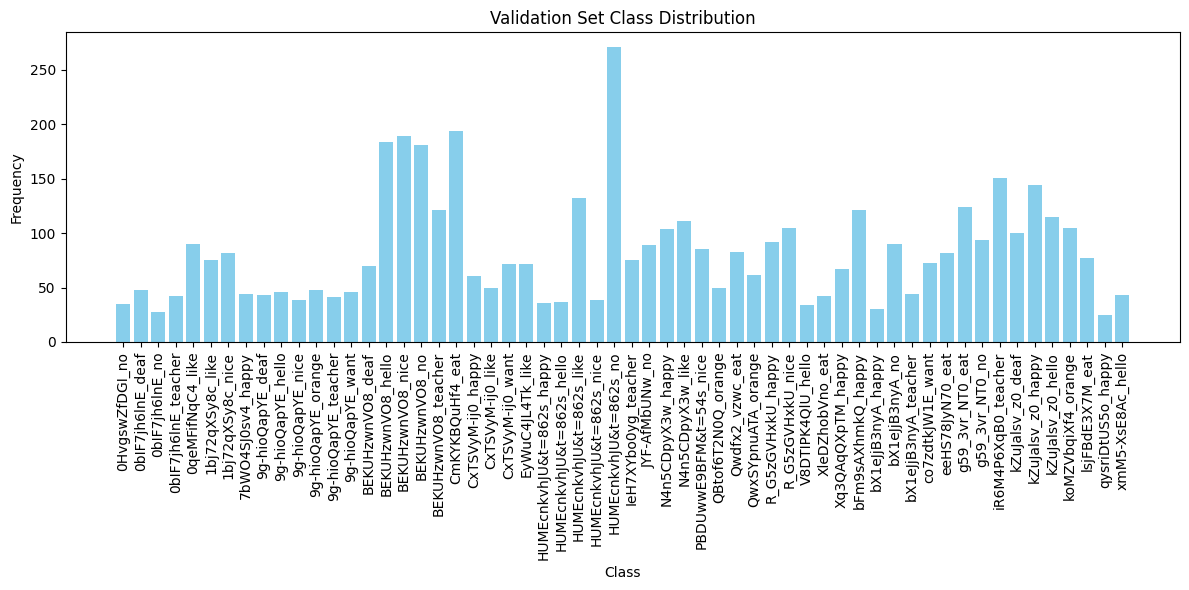

Average frame count per video: 73.58


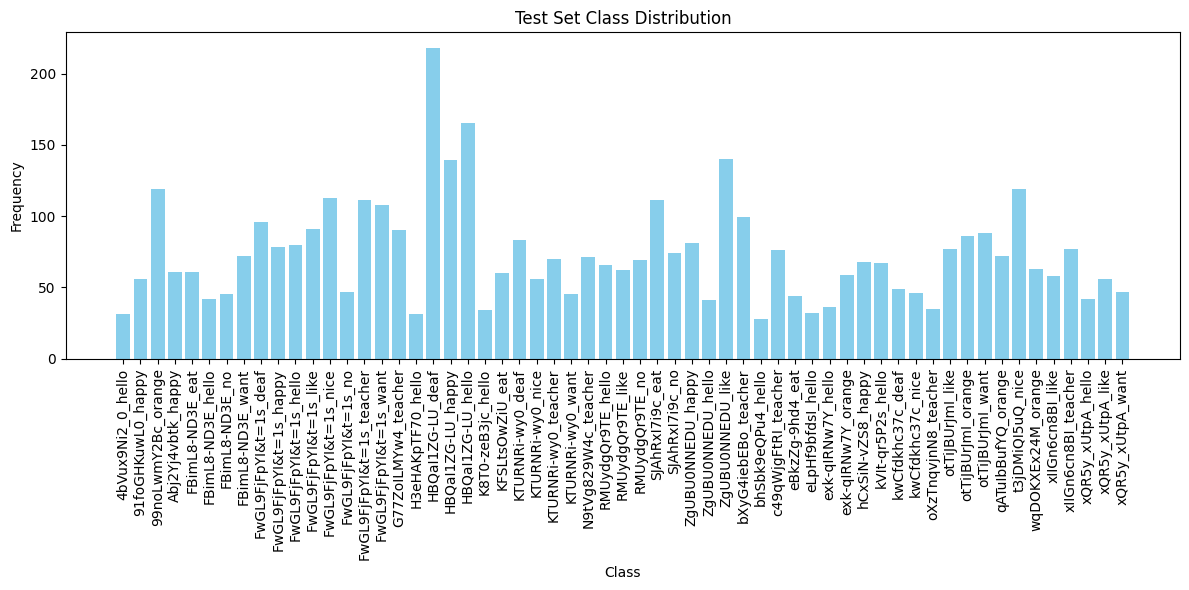

In [7]:
import matplotlib.pyplot as plt

def plot_class_distribution(df, title):
        # Group by video_id and count frames per video
    frame_counts = df.groupby('video_id')['frame'].count()
    
    # Calculate the average frame count
    avg_frame_count = frame_counts.mean()
    
    print(f"Average frame count per video: {avg_frame_count:.2f}")
    class_counts = df.groupby('video_id')['frame'].count()

    plt.figure(figsize=(12, 6))
    plt.bar(class_counts.index, class_counts.values, color='skyblue')
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Example usage
plot_class_distribution(train_df, "Training Set Class Distribution")
plot_class_distribution(val_df, "Validation Set Class Distribution")
plot_class_distribution(test_df, "Test Set Class Distribution")


NameError: name 'df' is not defined

## data perprocessing

In [14]:



import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from tqdm import tqdm

# Constants
MAX_SEQ_LENGTH = 150

def load_and_group_data(file_path):
    """Load CSV and group by video_id"""
    df = pd.read_csv(file_path)
    
    # Get landmark column names (exclude first 3: video_id, class, frame)
    landmark_columns = df.columns[3:].tolist()  # Now contains names like 'Face_LM_0_x'
    
    # Sort globally first
    df_sorted = df.sort_values(by=['video_id', 'frame'])
    return df_sorted, landmark_columns  # Return landmark column names

def interpolate_landmarks(features):
    """Fill missing hand landmarks using linear interpolation"""
    time = np.arange(features.shape[0])
    
    # Indices for left/right hand (assuming 21 landmarks each, 3 coordinates)
    LH_START, LH_END = 39*3, 60*3  # Adjust based on your actual column order
    RH_START, RH_END = 60*3, 81*3
    
    # Interpolate Left Hand
    valid_lh = np.any(features[:, LH_START:LH_END] != 0, axis=1)
    if sum(valid_lh) > 1:
        try:
            interp = interp1d(time[valid_lh], features[valid_lh, LH_START:LH_END], 
                            axis=0, kind='linear', fill_value="extrapolate")
            features[:, LH_START:LH_END] = interp(time)
        except ValueError:
            pass
    
    # Interpolate Right Hand
    valid_rh = np.any(features[:, RH_START:RH_END] != 0, axis=1)
    if sum(valid_rh) > 1:
        try:
            interp = interp1d(time[valid_rh], features[valid_rh, RH_START:RH_END], 
                            axis=0, kind='linear', fill_value="extrapolate")
            features[:, RH_START:RH_END] = interp(time)
        except ValueError:
            pass
    
    return features

def process_sequence(group, landmark_cols):
    """Process a single video sequence"""
    features = group[landmark_cols].values.astype(np.float32)  # Use column names
    label = group['class'].iloc[0]
    
    # Interpolation
    features = interpolate_landmarks(features)
    
    # Padding/Truncation
    if len(features) > MAX_SEQ_LENGTH:
        features = features[:MAX_SEQ_LENGTH]
    else:
        pad_length = MAX_SEQ_LENGTH - len(features)
        features = np.pad(features, ((0, pad_length), (0, 0)), 'constant')
    
    return features, label

def preprocess_dataset(file_path):
    """Full preprocessing pipeline"""
    df_sorted, landmark_cols = load_and_group_data(file_path)
    
    processed_data = []
    labels = []
    
    # Process each video sequence
    for video_id, group in tqdm(df_sorted.groupby('video_id')):
        seq, label = process_sequence(group, landmark_cols)
        processed_data.append(seq)
        labels.append(label)
    
    return np.array(processed_data), np.array(labels)

# Usage
if __name__ == "__main__":
    input_csv = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\test.csv"
    output_npz = "validate.npz"
    
    # Run preprocessing
    X, y = preprocess_dataset(input_csv)
    
    # Save processed data
    np.savez(output_npz, X=X, y=y)
    print(f"Saved preprocessed data to {output_npz}")
    print(f"Final dataset shape: {X.shape}")

100%|██████████| 59/59 [00:00<00:00, 1053.21it/s]

Saved preprocessed data to test.npz
Final dataset shape: (59, 150, 165)


In [26]:
data = np.load("test.npz")
test_X, test_y = data['X'], data['y']
print(test_y)

['hello' 'happy' 'orange' 'happy' 'eat' 'hello' 'no' 'want' 'deaf' 'happy'
 'hello' 'like' 'nice' 'no' 'teacher' 'want' 'teacher' 'hello' 'deaf'
 'happy' 'hello' 'hello' 'eat' 'deaf' 'nice' 'teacher' 'want' 'teacher'
 'hello' 'like' 'no' 'eat' 'no' 'happy' 'hello' 'like' 'teacher' 'hello'
 'teacher' 'eat' 'hello' 'hello' 'orange' 'happy' 'hello' 'deaf' 'nice'
 'teacher' 'like' 'orange' 'want' 'orange' 'nice' 'orange' 'like'
 'teacher' 'hello' 'like' 'want']


In [27]:
data = np.load("train.npz")
train_X, train_y = data['X'], data['y']
print(train_y)
print("=========================================================================================================================================")
print(train_X)


['teacher' 'deaf' 'no' 'teacher' 'orange' 'eat' 'no' 'deaf' 'hello' 'nice'
 'teacher' 'deaf' 'nice' 'eat' 'want' 'deaf' 'nice' 'hello' 'teacher'
 'orange' 'eat' 'orange' 'eat' 'no' 'want' 'deaf' 'hello' 'nice' 'no'
 'hello' 'like' 'hello' 'eat' 'teacher' 'orange' 'want' 'like' 'nice'
 'deaf' 'teacher' 'orange' 'eat' 'want' 'teacher' 'eat' 'happy' 'eat'
 'deaf' 'no' 'teacher' 'eat' 'deaf' 'happy' 'hello' 'like' 'nice' 'no'
 'want' 'happy' 'like' 'deaf' 'eat' 'like' 'no' 'teacher' 'hello' 'hello'
 'eat' 'like' 'eat' 'happy' 'teacher' 'nice' 'deaf' 'deaf' 'hello'
 'orange' 'teacher' 'orange' 'teacher' 'orange' 'like' 'no' 'nice' 'nice'
 'deaf' 'like' 'no' 'want' 'nice' 'orange' 'nice' 'teacher' 'teacher'
 'want' 'eat' 'like' 'teacher' 'orange' 'eat' 'hello' 'happy' 'happy'
 'nice' 'orange' 'hello' 'nice' 'eat' 'like' 'teacher' 'want' 'happy'
 'like' 'no' 'teacher' 'happy' 'like' 'want' 'like' 'want' 'teacher'
 'deaf' 'like' 'teacher' 'want' 'orange' 'want' 'orange' 'orange' 'orange'
 'ora

In [28]:
data = np.load("validate.npz")
val_X, val_y = data['X'], data['y']
print(val_y)
print("=========================================================================================================================================")
print(val_X)


['no' 'deaf' 'no' 'teacher' 'like' 'like' 'nice' 'happy' 'deaf' 'hello'
 'nice' 'orange' 'teacher' 'want' 'deaf' 'hello' 'nice' 'no' 'teacher'
 'eat' 'happy' 'like' 'want' 'like' 'happy' 'hello' 'like' 'nice' 'no'
 'teacher' 'no' 'happy' 'like' 'nice' 'orange' 'eat' 'orange' 'happy'
 'nice' 'hello' 'eat' 'happy' 'happy' 'happy' 'no' 'teacher' 'want' 'eat'
 'eat' 'no' 'teacher' 'deaf' 'happy' 'hello' 'orange' 'eat' 'happy'
 'hello']
[[[ 0.5302805   0.32571566 -0.8762118  ...  1.2846568  -0.5274444
    0.13046564]
  [ 0.51118314  0.31391206 -1.1110348  ...  1.2220458  -0.42664933
    0.11689191]
  [ 0.5104351   0.31148487 -0.9215086  ...  1.1594347  -0.32585424
    0.10331818]
  ...
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]]

 [[ 0.6323284   0.3545625  -0.22000918 ...  0.5776686   0.8210634
    0.0169622 ]
 

In [35]:
print("NaN in train_X:", np.isnan(train_X).any())
print("Inf in train_X:", np.isinf(train_X).any())

NaN in train_X: False
Inf in train_X: False


Label mapping: {np.int32(0): np.int64(0), np.int32(1): np.int64(1), np.int32(2): np.int64(2), np.int32(3): np.int64(3), np.int32(4): np.int64(4), np.int32(5): np.int64(5), np.int32(6): np.int64(6), np.int32(7): np.int64(7), np.int32(8): np.int64(8), np.int32(9): np.int64(9)}

Converted dtypes:
Train y: int32, Val y: int32, Test y: int32
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 385ms/step - accuracy: 0.0898 - loss: 0.1913 - val_accuracy: 0.1724 - val_loss: 0.1924 - learning_rate: 3.0000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - accuracy: 0.1658 - loss: 0.1771 - val_accuracy: 0.1724 - val_loss: 0.1880 - learning_rate: 3.0000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 282ms/step - accuracy: 0.1583 - loss: 0.1752 - val_accuracy: 0.1379 - val_loss: 0.1827 - learning_rate: 3.0000e-04
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.2259 - loss: 0.1616 - val_accuracy: 0.2069 - val_loss: 0.1790 - learning_rate: 3.0000e-04
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 

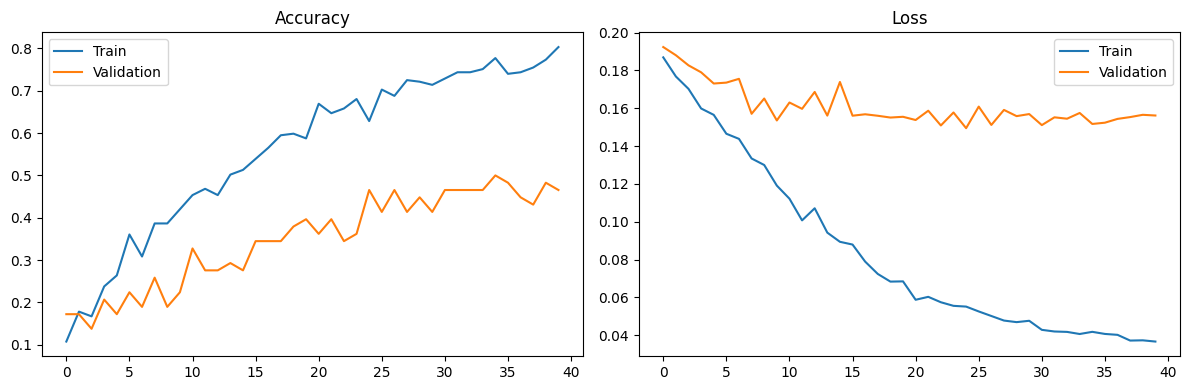

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# # Load data
# train_data = np.load("train.npz")
# val_data = np.load("validate.npz")
# test_data = np.load("test.npz")

# train_X, train_y = train_data['X'], train_data['y']
# val_X, val_y = val_data['X'], val_data['y']
# test_X, test_y = test_data['X'], test_data['y']

# Convert string labels to integers
le = LabelEncoder()
le.fit(np.concatenate([train_y, val_y, test_y]))

train_y = le.transform(train_y).astype(np.int32)
val_y = le.transform(val_y).astype(np.int32)
test_y = le.transform(test_y).astype(np.int32)

# Verify conversion
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nConverted dtypes:")
print(f"Train y: {train_y.dtype}, Val y: {val_y.dtype}, Test y: {test_y.dtype}")

# Configure GPU acceleration (temporarily disable mixed precision for debugging)
tf.keras.mixed_precision.set_global_policy('float32')

# Constants
SEQ_LENGTH = train_X.shape[1]
NUM_FEATURES = train_X.shape[2]
NUM_CLASSES = len(le.classes_)

# Model Architecture
def create_model():
    return tf.keras.Sequential([
        layers.Input(shape=(SEQ_LENGTH, NUM_FEATURES)),
        layers.Masking(mask_value=0.0),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

# Compute class weights with integer labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_y),
    y=train_y
).astype(np.float32)

# Focal Loss with integer labels
def sparse_focal_loss(gamma=2.0):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=NUM_CLASSES)
        
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = tf.reduce_mean(tf.pow(1 - y_pred, gamma) * cross_entropy, axis=1)
        weighted_loss = loss * tf.reduce_sum(class_weights_tensor * y_true, axis=1)
        
        return tf.reduce_mean(weighted_loss)
    return loss

# Compile and train
model = create_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=sparse_focal_loss(gamma=2.0),
    metrics=['accuracy']
)

history = model.fit(
    train_X.astype(np.float32),
    train_y,
    validation_data=(val_X.astype(np.float32), val_y),
    epochs=100,
    batch_size=32,
    callbacks=[
        callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ]
)

# Evaluation
model = tf.keras.models.load_model(
    "best_model.keras",
    custom_objects={'loss': sparse_focal_loss(gamma=2.0)}
)
test_pred = model.predict(test_X.astype(np.float32))
test_pred_classes = np.argmax(test_pred, axis=1)

print("\nTest Performance:")
print(classification_report(test_y, test_pred_classes))
print("Confusion Matrix:")
print(confusion_matrix(test_y, test_pred_classes))

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [42]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load and prepare data
# train_data = np.load("train.npz")
# val_data = np.load("validate.npz")
# test_data = np.load("test.npz")

# train_X, train_y = train_data['X'], train_data['y']
# val_X, val_y = val_data['X'], val_data['y']
# test_X, test_y = test_data['X'], test_data['y']

# Convert string labels to integers
le = LabelEncoder()
le.fit(np.concatenate([train_y, val_y, test_y]))
train_y = le.transform(train_y)
val_y = le.transform(val_y)
test_y = le.transform(test_y)

# Data parameters
SEQ_LENGTH = train_X.shape[1]
NUM_FEATURES = train_X.shape[2]
NUM_CLASSES = len(le.classes_)

# Fixed model architecture
def create_model():
    inputs = layers.Input(shape=(SEQ_LENGTH, NUM_FEATURES))
    
    # Masking with explicit float conversion
    masked = layers.Masking(mask_value=0.0)(inputs)
    mask = layers.Lambda(
        lambda x: tf.cast(tf.math.not_equal(x[:, :, 0], 0), tf.float32)
    )(inputs)  # Create explicit mask
    
    # First BiLSTM with proper masking
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(masked)
    
    # Simplified attention mechanism
    attn = layers.Attention(use_scale=False)([x, x], mask=[mask, mask])
    x = layers.Concatenate()([x, attn])
    x = layers.Dropout(0.3)(x)
    
    # Final processing
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', 
                   kernel_regularizer=regularizers.l2(0.01))(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs)

# Class weighting
class_weights = {i: 1/(count/len(train_y)) 
                for i, count in enumerate(np.bincount(train_y))}

# Compile model
model = create_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

# Train
history = model.fit(
    train_X.astype(np.float32),
    train_y,
    validation_data=(val_X.astype(np.float32), val_y),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Evaluation
model = tf.keras.models.load_model("best_model.keras")
test_pred = model.predict(test_X.astype(np.float32))
test_pred_classes = np.argmax(test_pred, axis=1)

print("\nTest Performance:")
print(classification_report(test_y, test_pred_classes, target_names=le.classes_))
print("Confusion Matrix:")
print(confusion_matrix(test_y, test_pred_classes))

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

Epoch 1/100


TypeError: Exception encountered when calling BroadcastTo.call().

[1mFailed to convert elements of (None, 150, 256) to Tensor. Consider casting elements to a supported type. See https://www.tensorflow.org/api_docs/python/tf/dtypes for supported TF dtypes.[0m

Arguments received by BroadcastTo.call():
  • x=tf.Tensor(shape=(None, 150, 1), dtype=bool)

In [46]:
train_X[0]

array([[ 0.50148946,  0.29185489, -0.92979193, ...,  1.06586838,
         1.02135539, -0.1068604 ],
       [ 0.48861432,  0.27232814, -1.15070283, ...,  1.04321051,
         0.97349149, -0.10121274],
       [ 0.48863524,  0.25277886, -0.98991346, ...,  1.02055275,
         0.92562759, -0.09556508],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])